# Создание моделей машинного обучения для предсказания уровня удовлетворенности сотрудника и вероятности увольнения сотрудника из компании

HR-департамент компании «Работа с заботой» предоставил данные с характеристиками сотрудников, включая уровень удовлетворённости работой. Этот показатель был рассчитан на основе результатов анкетирования: сотрудники заполняли опросник обратной связи, по результатам которого определялась доля удовлетворённости в диапазоне от 0 до 1, где 0 — полностью неудовлетворён, 1 — полностью удовлетворён.

В рамках проекта сформулированы две задачи:
1) Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.

2) Построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

# Задача 1:  Предсказание уровня удовлетворённости сотрудника

Для этой задачи заказчик предоставил данные с признаками:
- id — уникальный идентификатор сотрудника;
- dept — отдел, в котором работает сотрудник;
- level — уровень занимаемой должности;
- workload — уровень загруженности сотрудника;
- employment_years — длительность работы в компании (в годах);
- last_year_promo — показывает, было ли повышение за последний год;
- last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
- supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
- salary — ежемесячная зарплата сотрудника;
- job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

## Первичный анализ данных

In [1]:
!pip install phik -q 
!pip install -U scikit-learn -q

In [2]:
#Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import phik
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder, 
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
)
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import (
    roc_auc_score,
    make_scorer
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#Загружаю необходимые файлы и сохраняю их в соответствующие датафреймы
train_job_satisfaction_rate_df = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
test_features_df = pd.read_csv('/datasets/test_features.csv')
test_target_job_satisfaction_rate_df = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv') 

In [4]:
#Вывожу первые 5 строк датафрейма 'train_job_satisfaction_rate_df' и общую информацию о нем
display(train_job_satisfaction_rate_df.head(5))
print(train_job_satisfaction_rate_df.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB
None


**Вывод:** В датафрейме 'train_job_satisfaction_rate_df' содержатся данные о сотрудниках для тренировочной выборки. Всего в датафрейме 4000 значений и 10 параметров:
- id — уникальный идентификатор сотрудника;
- dept — отдел, в котором работает сотрудник;
- level — уровень занимаемой должности;
- workload — уровень загруженности сотрудника;
- employment_years — длительность работы в компании (в годах);
- last_year_promo — показывает, было ли повышение за последний год;
- last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
- supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
- salary — ежемесячная зарплата сотрудника;
- job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак. 

В датафрейме присутствуют пропуски в столбцах 'dept' (6 пропусков) и 'level' (4 пропуска). Все столбцы имеют верный тип данных.

In [5]:
#Вывожу первые 5 строк датафрейма 'test_features_df' и общую информацию о нем
display(test_features_df.head(5))
print(test_features_df.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB
None


**Вывод:** В датафрейме 'test_features_df' содержатся входные данные о сотрудниках для тестовой выборки. Всего в датафрейме 2000 значений и 9 упомянутых выше параметров (без целевого признака 'job_satisfaction_rate') В датафрейме присутствуют пропуски в столбцах 'dept' (2 пропуска) и 'level' (1 пропуск). Все столбцы имеют верный тип данных.

In [6]:
#Вывожу первые 5 строк датафрейма 'test_target_job_satisfaction_rate_df' и общую информацию о нем
display(test_target_job_satisfaction_rate_df.head(5))
print(test_target_job_satisfaction_rate_df.info())

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
None


**Вывод:** В датафрейме 'test_target_job_satisfaction_rate_df' содержатся значения целевого признака 'job_satisfaction_rate' для тестовой выборки. Всего в датафрейме 2000 значений и 2 параметра:
- id — уникальный идентификатор сотрудника;
- job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак. 
В датафрейме нет пропусков и все столбцы имеют верный тип данных.

## Предобработка данных

In [7]:
#Создаю пайплайны для обработки пропусков и неявных дубликатов в столбцах 'dept' и 'level'
l = ['level', 'dept']

#Создаю функцию для преобразования пустых строк в np.nan
to_nan = FunctionTransformer(lambda X: pd.DataFrame(X).replace(' ', np.nan), validate=False)

miss_val_pipe = Pipeline(
    [
        ('to_nan', to_nan),
        ('impute', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

miss_val_process = ColumnTransformer(
    [
        ('miss_val_proc', miss_val_pipe, l)
    ],
    remainder='passthrough'
)

In [8]:
#Применяю пайплайн для 'train_job_satisfaction_rate_df'
#Убираю таргет из тренировочного датафрейма для обучения 
X_train_wo_tar = train_job_satisfaction_rate_df.drop(columns=['job_satisfaction_rate'])
X_train_wo_tar_clean = miss_val_process.fit_transform(X_train_wo_tar)
new_columns_train = l + [col for col in X_train_wo_tar.columns if col not in l]

#Оборачиваю результат в датафрейм
X_train_wo_tar = pd.DataFrame(
    miss_val_process.fit_transform(X_train_wo_tar),
    columns=new_columns_train,
    index=X_train_wo_tar.index
)

#Добавляю обратно таргет в тренировочный датафрейм после трансформации
X_train_wo_tar['job_satisfaction_rate'] = train_job_satisfaction_rate_df['job_satisfaction_rate']
train_job_satisfaction_rate_df = X_train_wo_tar

**Вывод:** Пропущенные значения и неявные дубликаты в столбцах dept, level в датафрейме train_job_satisfaction_rate_df были заменены на наиболее часто встречающиеся значения (моды) соответствующих признаков.

In [9]:
#Применяю пайплайн для 'test_features_df'
new_columns_test = l + [col for col in test_features_df.columns if col not in l]
test_idx = test_features_df.index

test_features_df_clean = miss_val_process.transform(test_features_df)
test_features_df_clean = pd.DataFrame(
    test_features_df_clean,
    columns=new_columns_test,
    index=test_idx)

**Вывод:** Пропущенные значения и неявные дубликаты в столбцах dept, level в датафрейме test_features_df были заменены на наиболее часто встречающиеся значения (моды) соответствующих признаков.

In [10]:
#Проверяю наличие неявных дубликатов в датафрейме 'train_job_satisfaction_rate_df'
train_job_satisfaction_rate_df_dub_check = ['dept', 'level', 'workload', 'employment_years', 'last_year_promo', 'last_year_violations', 'supervisor_evaluation']
for c in train_job_satisfaction_rate_df_dub_check:
    print(train_job_satisfaction_rate_df[c].unique())
#Исправляю ошибку в слове'senior' в датафрейме 'train_job_satisfaction_rate_df'
train_job_satisfaction_rate_df['level'] = train_job_satisfaction_rate_df['level'].str.replace('sinior', 'senior')

['sales' 'hr' 'technology' 'purchasing' 'marketing']
['junior' 'middle' 'sinior']
['medium' 'high' 'low']
[2 1 4 7 9 6 3 10 8 5]
['no' 'yes']
['no' 'yes']
[1 5 2 3 4]


In [11]:
#Проверяю изменения в датафрейме 'train_job_satisfaction_rate_df'
print(train_job_satisfaction_rate_df['level'].unique())

['junior' 'middle' 'senior']


**Вывод:** В датафрейме 'train_job_satisfaction_rate_df' была исправлена ошибка в слове 'senior' в столбце 'level'.

In [12]:
#Для цикла использую список для датафрейма 'train_job_satisfaction_rate_df', так как проверяем те же признаки
for c in train_job_satisfaction_rate_df_dub_check:
    print(test_features_df[c].unique())
#Исправляю ошибку в слове'senior' в датафрейме 'test_features_df'
test_features_df['level'] = test_features_df['level'].str.replace('sinior', 'senior')

['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
['junior' 'middle' 'sinior' nan]
['medium' 'low' 'high' ' ']
[ 2  1  5  6  3  9  7  4  8 10]
['no' 'yes']
['no' 'yes']
[5 4 3 1 2]


In [13]:
#Проверяю изменения в датафрейме 'test_features_df'
for c in train_job_satisfaction_rate_df_dub_check:
    print(test_features_df[c].unique())

['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
['junior' 'middle' 'senior' nan]
['medium' 'low' 'high' ' ']
[ 2  1  5  6  3  9  7  4  8 10]
['no' 'yes']
['no' 'yes']
[5 4 3 1 2]


**Вывод:** В датафрейме 'test_features_df' была исправлена ошибка в слове 'senior' в столбце 'level'.

In [14]:
#Проверяю наличие неявных дубликатов в датафреймах 
print('Кол-во явных дубликатов в train_job_satisfaction_rate_df', train_job_satisfaction_rate_df.duplicated(subset=['id', 'dept', 'level', 'employment_years']).sum())
print('Кол-во явных дубликатов в test_features_df', test_features_df.duplicated(subset=['id', 'dept', 'level', 'employment_years']).sum())
print('Кол-во явных дубликатов в test_target_job_satisfaction_rate_df', test_target_job_satisfaction_rate_df.duplicated(subset=['id']).sum())

Кол-во явных дубликатов в train_job_satisfaction_rate_df 0
Кол-во явных дубликатов в test_features_df 0
Кол-во явных дубликатов в test_target_job_satisfaction_rate_df 0


**Вывод:** В датафреймах отсутствуют явные дубликаты.

**Общий вывод:** 
В результате проведенной предобработки данных были сделаны следующие выводы о датафреймах:
1) train_job_satisfaction_rate_df
Содержит данные о сотрудниках для тренировочной выборки.
Размер до очистки: 4000 строк × 10 столбцов.
Столбцы:
- id — уникальный идентификатор сотрудника;
- dept — отдел;
- level — уровень занимаемой должности;
- workload — уровень загруженности;
- employment_years — стаж работы в компании (в годах);
- last_year_promo — было ли повышение за последний год;
- last_year_violations — были ли нарушения трудового договора;
- supervisor_evaluation — оценка работы сотрудника от руководителя;
- salary — ежемесячная зарплата;
- job_satisfaction_rate — целевой признак (уровень удовлетворённости работой).

Обнаруженные проблемы и действия:
Пропуски:
- dept: 6 строк
- level: 4 строки\
Ошибка в значении level: опечатка "sinior" → исправлено на "senior"; \
Пропуски в строках с пропущенными значениями были заменены модой соответствующих признаков.

Типы данных всех столбцов корректны.

2) test_features_df
Содержит данные о сотрудниках для тестовой выборки (без целевого признака).
Размер до очистки: 2000 строк × 9 столбцов.

Обнаруженные проблемы и действия:
Пропуски:
- dept: 2 строки
- level: 1 строка \
Ошибки: \
Опечатка "sinior" → исправлена на "senior" в столбце level; \
Выявлены строки с пустыми значениями (' ') в столбцах dept и workload. \
Пропуски в строках с пропущенными и некорректными значениями были заменены модой соответствующих признаков.

Типы данных всех столбцов корректны.

3) test_target_job_satisfaction_rate_df
Содержит значения целевого признака job_satisfaction_rate для тестовой выборки.
Размер: 2000 строк × 2 столбца: 
- id — уникальный идентификатор сотрудника;
- job_satisfaction_rate — целевой признак.

Данные полные — пропусков нет, типы данных корректны.



## Исследовательский анализ

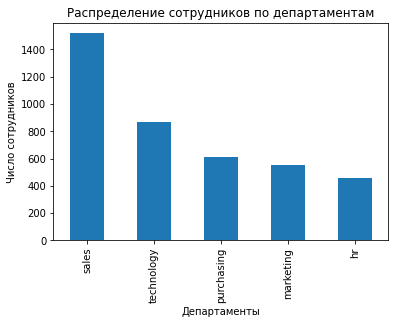

In [15]:
#Строю столбчатую диаграмму для параметра 'dept' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['dept'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по департаментам')
plt.ylabel('Число сотрудников')
plt.xlabel('Департаменты')
plt.show()

**Вывод:** Больше всего сотрудников работает в департаменте sales — около 1500 человек. Почти в два раза меньше — в департаменте technology, где занято примерно 900 сотрудников. В purchasing работают около 700 человек, а в marketing — немного меньше, около 600. HR является самым небольшим департаментом по численности персонала, около 500.

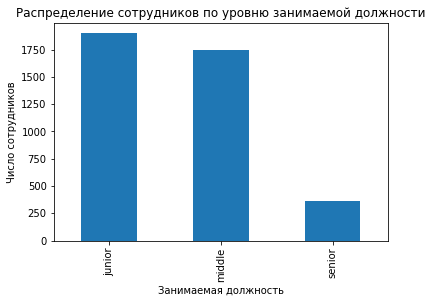

In [16]:
#Строю столбчатую диаграмму для параметра 'level' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['level'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню занимаемой должности')
plt.ylabel('Число сотрудников')
plt.xlabel('Занимаемая должность')
plt.show()

**Вывод:** Наибольшее количество сотрудников занимает должность junior (около 1875). Немного уступает по численности категория middle (1750). А вот senior-сотрудников существенно меньше (375) — их почти в пять раз меньше, чем junior-специалистов.

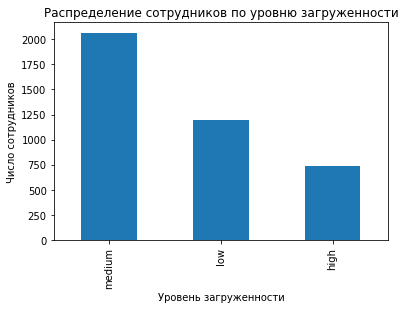

In [17]:
#Строю столбчатую диаграмму для параметра 'workload' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['workload'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню загруженности')
plt.ylabel('Число сотрудников')
plt.xlabel('Уровень загруженности')
plt.show()

**Вывод:** Наиболее распространённый уровень загруженности — medium, его имеют около 2000 сотрудников. На втором месте — уровень low с примерно 1250 сотрудниками, а наименьшее число сотрудников — около 750 — задействовано на уровне high.

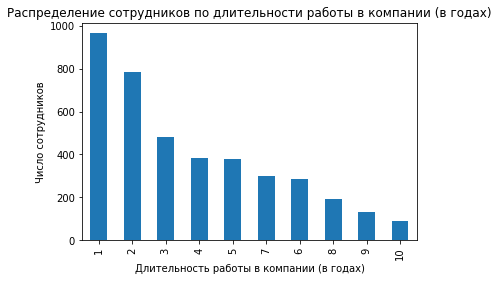

In [18]:
#Строю столбчатую диаграмму для параметра 'employment_years' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['employment_years'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по длительности работы в компании (в годах)')
plt.ylabel('Число сотрудников')
plt.xlabel('Длительность работы в компании (в годах)')
plt.show()

**Вывод:** Наибольшее количество сотрудников работает в компании от 1 до 2 лет. Наименьшая доля сотрудников работает в компании 10 лет.

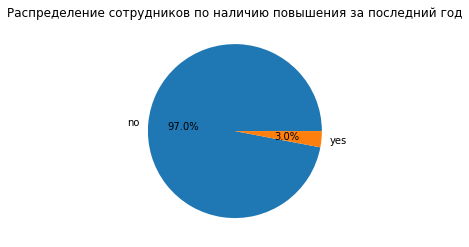

In [19]:
#Строю столбчатую диаграмму для параметра 'last_year_promo' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['last_year_promo'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию повышения за последний год')
plt.ylabel('')
plt.show()

**Вывод:** За последний год только 3% сотрудников получили повышение.

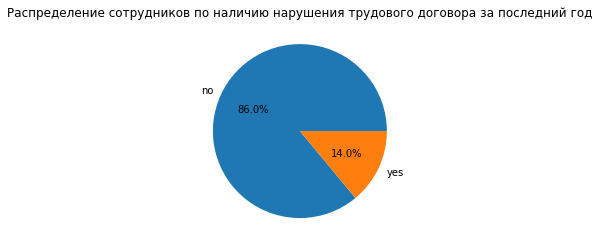

In [20]:
#Строю столбчатую диаграмму для параметра 'last_year_violations' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['last_year_violations'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию нарушения трудового договора за последний год')
plt.ylabel('')
plt.show()

**Вывод:** За последний год трудовой договор нарушили 14% сотрудников.

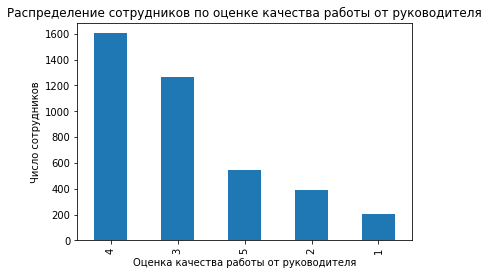

In [21]:
#Строю столбчатую диаграмму для параметра 'supervisor_evaluation' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['supervisor_evaluation'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по оценке качества работы от руководителя')
plt.ylabel('Число сотрудников')
plt.xlabel('Оценка качества работы от руководителя')
plt.show()

**Вывод:** Большинство сотрудников — около 1600 человек — получали от руководителей оценку 4. На втором месте по частоте — оценка 3, которую получили примерно 1250 сотрудников. Наименее распространённой является оценка 1, её сотрудники получали крайне редко.

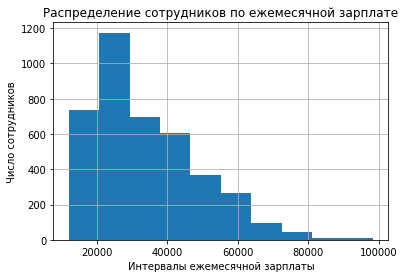

In [22]:
#Строю гистограмму для параметра 'salary' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['salary'].hist();
plt.title('Распределение сотрудников по ежемесячной зарплате')
plt.ylabel('Число сотрудников')
plt.xlabel('Интервалы ежемесячной зарплаты')
plt.show()

**Вывод:** Ежемесячная зарплата сотрудников находится в интервале от 8000 до 100000, при этом пик распределения приходится на зарплату в диапазоне 20000-30000. Распределение левостороннее асимметричное, то есть скошено в сторону низких значений, что может быть важным фактором в нашей модели.

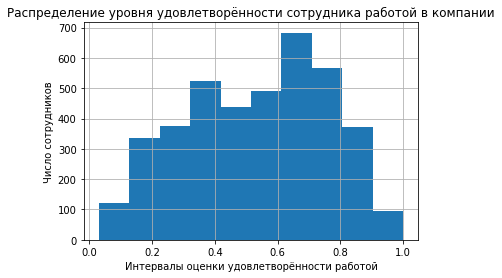

In [23]:
#Строю гистограмму для параметра 'job_satisfaction_rate' в датафрейме train_job_satisfaction_rate_df
train_job_satisfaction_rate_df['job_satisfaction_rate'].hist();
plt.title('Распределение уровня удовлетворённости сотрудника работой в компании')
plt.ylabel('Число сотрудников')
plt.xlabel('Интервалы оценки удовлетворённости работой')
plt.show()

**Вывод:** Уровень удовлетворённости сотрудника работой варьируется от 0 до 1, при этом большинство значений сосредоточено в диапазоне от 0.6 до 0.8. Распределение правостороннее асимметричное, что указывает на то, что большинство сотрудников довольны работой в компании.

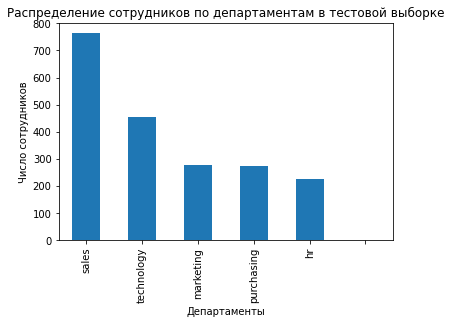

In [24]:
#Строю столбчатую диаграмму для параметра 'dept' в датафрейме test_features_df
test_features_df['dept'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по департаментам в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Департаменты')
plt.show()

**Вывод:** Больше всего сотрудников в тестовой выборке работает в департаменте sales — около 750 человек. Почти в два раза меньше — в департаменте technology, где занято примерно 450 сотрудников. В marketing, как и в purchasing работают около 275 человек. Им чуть уступает hr департамент с 250 сотрудниками.

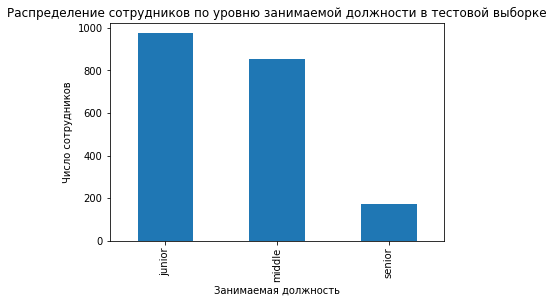

In [25]:
#Строю столбчатую диаграмму для параметра 'level' в датафрейме test_features_df
test_features_df['level'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню занимаемой должности в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Занимаемая должность')
plt.show()

**Вывод:** Наибольшее количество сотрудников занимает должность junior (почти 1000) в тестовой выборке. Немного уступает по численности категория middle (около 850). А вот senior-сотрудников существенно меньше (около 200) — их почти в пять раз меньше, чем junior-специалистов.

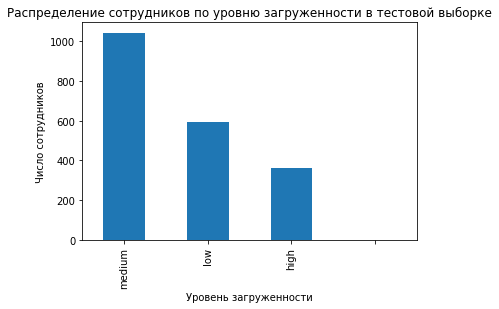

In [26]:
#Строю столбчатую диаграмму для параметра 'workload' в датафрейме test_features_df
test_features_df['workload'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню загруженности в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Уровень загруженности')
plt.show()

**Вывод:** Наиболее распространённый уровень загруженности в тестовой выборке — medium, его имеют около 1000 сотрудников. На втором месте — уровень low с примерно 600 сотрудниками, а наименьшее число сотрудников — около 380 — задействовано на уровне high.

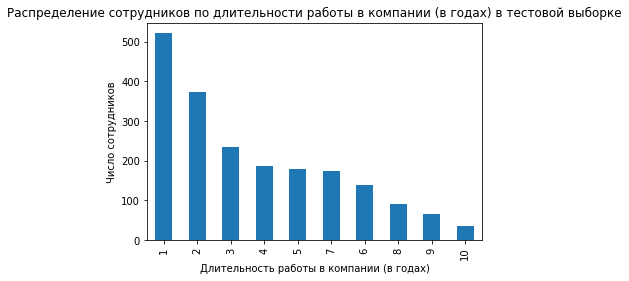

In [27]:
#Строю столбчатую диаграмму для параметра 'employment_years' в датафрейме test_features_df
test_features_df['employment_years'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по длительности работы в компании (в годах) в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Длительность работы в компании (в годах)')
plt.show()

**Вывод:** Наибольшее количество сотрудников в тестовой выборке работает в компании от 1 до 2 лет. Наименьшая доля сотрудников работает в компании 10 лет.

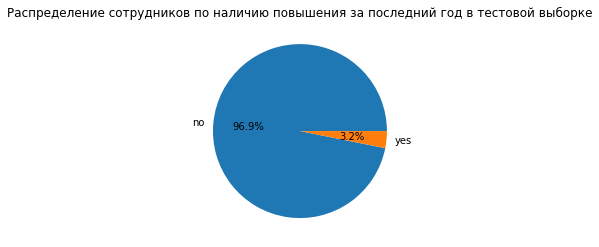

In [28]:
#Строю круговую диаграмму для параметра 'last_year_promo' в датафрейме test_features_df
test_features_df['last_year_promo'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию повышения за последний год в тестовой выборке')
plt.ylabel('')
plt.show()

**Вывод:**  За последний год только 3.2% сотрудников получили повышение.

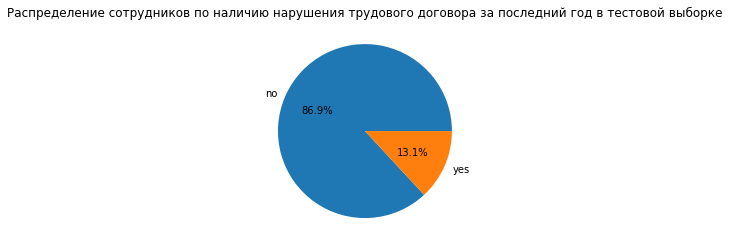

In [29]:
#Строю круговую диаграмму для параметра 'last_year_violations' в датафрейме test_features_df
test_features_df['last_year_violations'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию нарушения трудового договора за последний год в тестовой выборке')
plt.ylabel('')
plt.show()

**Вывод:** За последний год трудовой договор нарушили 13.1% сотрудников.

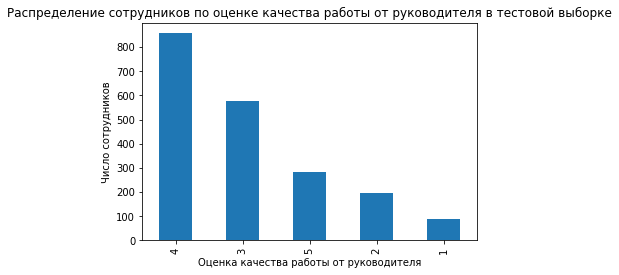

In [30]:
#Строю столбчатую диаграмму для параметра 'supervisor_evaluation' в датафрейме test_features_df
test_features_df['supervisor_evaluation'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по оценке качества работы от руководителя в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Оценка качества работы от руководителя')
plt.show()

**Вывод:** Большинство сотрудников — около 850 человек — получали от руководителей оценку 4. На втором месте по частоте — оценка 3, которую получили примерно 675 сотрудников. Наименее распространённой является оценка 1, её сотрудники получали крайне редко (около 100 сотрудников).

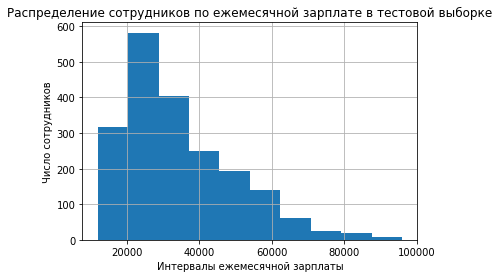

In [31]:
#Строю гистограмму для параметра 'salary' в датафрейме test_features_df
test_features_df['salary'].hist();
plt.title('Распределение сотрудников по ежемесячной зарплате в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Интервалы ежемесячной зарплаты')
plt.show()

**Вывод:** Ежемесячная зарплата сотрудников в тестовой выборке находится в интервале от 8000 до 100000, при этом пик распределения приходится на зарплату в диапазоне 20000-30000. Распределение левостороннее асимметричное, то есть скошено в сторону низких значений, что может быть важным фактором в нашей модели.

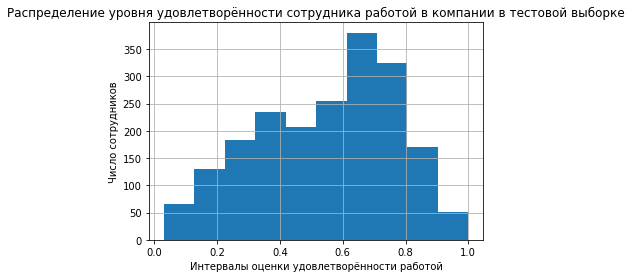

In [32]:
#Строю гистограмму для параметра 'job_satisfaction_rate' в датафрейме test_target_job_satisfaction_rate_df
test_target_job_satisfaction_rate_df['job_satisfaction_rate'].hist();
plt.title('Распределение уровня удовлетворённости сотрудника работой в компании в тестовой выборке')
plt.ylabel('Число сотрудников')
plt.xlabel('Интервалы оценки удовлетворённости работой')
plt.show()

**Вывод:** Уровень удовлетворённости сотрудника работой в тестовой выборке варьируется от 0 до 1, при этом большинство значений сосредоточено в диапазоне от 0.6 до 0.8. Распределение правостороннее асимметричное, что указывает на то, что большинство сотрудников довольны работой в компании.

**Промежуточный вывод** \
Распределение признаков в тестовой выборке схожи с распределением признаков в тренировочной выборке. В ходе исследовательского анализа были сделаны следующие наблюдения:

- Департамент \
Наибольшее количество сотрудников в тестовой выборке работает в департаменте sales. Существенно меньше заняты в департаменте technology, ещё меньше — в marketing, purchasing и hr.
- Уровень должности (level) \
Больше всего сотрудников занимают должность junior. Следом идёт категория middle, а senior-специалистов — значительно меньше. Это указывает на перекос в сторону менее опытных сотрудников.
- Загруженность (workload) \
Наиболее распространённый уровень загруженности — medium. Меньше сотрудников с уровнем low, и ещё меньше — на уровне high. Это говорит о стремлении компании к сбалансированной загрузке.
- Опыт работы (employment_years) \
Большинство сотрудников работают в компании от 1 до 2 лет, а наименьшая доля — это сотрудники с очень длительным стажем. Это может отражать высокую текучесть персонала или активный рост компании.
- Повышение за последний год (last_year_promo) \
Повышение получило лишь небольшое число сотрудников. Это может свидетельствовать о низкой скорости карьерного роста или строгих критериях для продвижения.
- Нарушения трудового договора (last_year_violations) \
Часть сотрудников нарушила условия трудового договора за последний год, но таких — меньшинство.
- Оценка от руководителя (supervisor_evaluation) \
Большинство сотрудников получили высокие оценки от руководителей. Наиболее частыми являются оценки 4 и 3, в то время как низкие оценки встречаются редко, что указывает на хорошую квалификацию сотрудников.
- Ежемесячная зарплата (salary) \
Зарплаты сотрудников распределены неравномерно: основная масса сотрудников получает заработную плату в диапазоне низких значений, что может быть важным фактором в нашей модели
- Уровень удовлетворённости (job_satisfaction_rate) \
Уровень удовлетворённости сотрудников варьируется от минимального до максимального, но большая часть значений сосредоточена в средне-высоком диапазоне, что указывает на то, что сотрудники в основном довольны работой в компании.

## Подготовка данных

In [33]:
#Объединяю данных датафреймов 'test_features_df' и 'test_target_job_satisfaction_rate_df' по индексу для дальнейшего анализа
merged_test_df = pd.merge(test_features_df, test_target_job_satisfaction_rate_df, on='id', how='outer')
#Вывожу размерности получившегося датафрейма
print(merged_test_df.shape)

(2000, 10)


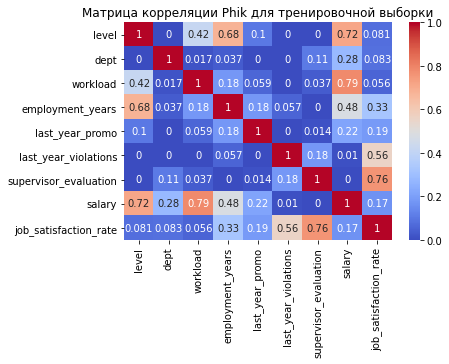

In [34]:
#Строю матрицу корреляции для тренировочной выборки
corr_matrix_train = train_job_satisfaction_rate_df.drop(columns='id').phik_matrix(interval_cols = ['job_satisfaction_rate', 'salary'])
sns.heatmap(corr_matrix_train, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции Phik для тренировочной выборки')
plt.show()

**Вывод:** В результате корреляционного анализа тренировочной выборки были выявлены несколько заметных взаимосвязей между признаками:

Сильная высокая положительная корреляция наблюдается между ежемесячной зарплатой и:
- уровнем занимаемой должности (0.72)
- уровнем загруженности (0.79) \
Это указывает на то, что зарплата существенно зависит как от должности, так и от объёма выполняемой работы.

Также была выявлена высокая корреляция между:
- оценкой руководителя и уровнем удовлетворённости сотрудника (0.76), что логично — положительная оценка напрямую влияет на восприятие сотрудником своей работы.
- стажем в компании и уровнем должности (0.68), что отражает естественное продвижение по карьерной лестнице со временем.

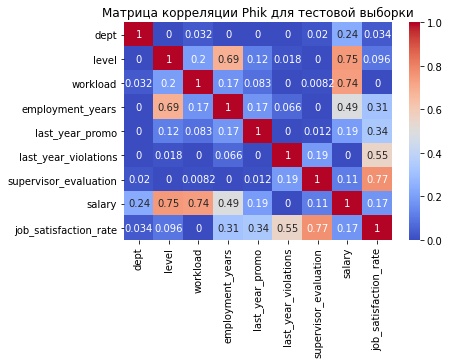

In [35]:
#Делаем корреляционный анализ для тестовой выборки
corr_matrix_test = merged_test_df.drop(columns='id').phik_matrix(interval_cols = ['job_satisfaction_rate', 'salary'])
sns.heatmap(corr_matrix_test, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции Phik для тестовой выборки')
plt.show()

**Вывод:** В результате корреляционного анализа тестовой выборки были выявлены несколько заметных взаимосвязей между признаками:

Сильная высокая положительная корреляция наблюдается между ежемесячной зарплатой и:
- уровнем занимаемой должности (0.75)
- уровнем загруженности (0.74) \
Это указывает на то, что зарплата существенно зависит как от должности, так и от объёма выполняемой работы.

Также была выявлена высокая корреляция между:
- оценкой руководителя и уровнем удовлетворённости сотрудника (0.77), что логично — положительная оценка напрямую влияет на восприятие сотрудником своей работы.
- стажем в компании и уровнем должности (0.69), что отражает естественное продвижение по карьерной лестнице со временем.

In [36]:
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Сохраняю переменные целевого признака и входных признаков в X_train, X_test, y_train, y_test, исключив 'id'
X_train = train_job_satisfaction_rate_df.drop(columns=['id', 'job_satisfaction_rate'])
X_test = merged_test_df.drop(columns=['id','job_satisfaction_rate'])
y_train = train_job_satisfaction_rate_df['job_satisfaction_rate']
y_test = merged_test_df['job_satisfaction_rate']

In [37]:
#Проверяю размерности получившихся df
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

#Создаю списки категориальных и количественных признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

(4000, 8) (2000, 8) (4000,) (2000,)


In [38]:
#Создаю пайплайн для подготовки признаков из списка ohe_columns через заполнение пропусков и OHE-кодирование  
ohe_pipe = Pipeline(
    [
        (
            'SimpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe',
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        )
    ]
)

In [39]:
#Создаю пайплайн для подготовки признаков из списка ord_columns через заполнение пропусков и Ordinal-кодирование  
ord_pipe = Pipeline(
    [
        (
            'SimpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder( 
                categories=[['junior', 'middle', 'senior'], ['low', 'medium', 'high']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
        
    ]
)

In [40]:
#Создаю пайплайн для подготовки признаков из списка num_columns через заполнение пропусков и MinMaxScaler()
num_pipe = Pipeline(
    [
        (
            'SimpleImputer_num',
            SimpleImputer(missing_values=np.nan, strategy='mean')
        ),
        (
            'num',
            MinMaxScaler()
        )
    ]
)


#Создаю общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', num_pipe, num_columns), 
        ('ord', ord_pipe, ord_columns)
    ],
    remainder='passthrough'
)

## Обучение моделей

In [41]:
#Пишу функцию для подсчета метрики SMAPE
def smape_calc(y_test, y_pred):
    y_test = np.array(y_test).ravel()
    y_pred = np.array(y_pred).ravel()
    
    numerator = np.abs(y_test - y_pred)
    denominator = (np.abs(y_test) + np.abs(y_pred)) / 2
    smape = 100 * np.mean(numerator / denominator)
    return smape
smape_scorer = make_scorer(smape_calc, greater_is_better=False)

In [42]:
#Создаю итоговый пайплайн через подготовку данных и модели 
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeRegressor(random_state=RANDOM_STATE)) #placeholder
    ]
)

#Создаю словарь с гиперпараметрами для перебора в GridSearchCV
param = {
    'preprocessor__num':[
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    'models': [
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        LinearRegression()
    ]
}

#Ищу лучшие гиперпараметры и модель через GridSearchCV
rs = RandomizedSearchCV(
    pipe_final,
    param,
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1
)

In [43]:
rs.fit(X_train, y_train)

print('Лучшая модель и её параметры при RandomizedSearchCV:\n\n', rs.best_estimator_, -rs.best_score_)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучшая модель и её параметры при RandomizedSearchCV:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('SimpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('num', Robus

**Вывод:** По результатам подбора гиперпараметров с использованием RandomizedSearchCV, наилучшей моделью стала DecisionTreeRegressor(random_state=42), показавшая среднее SMAPE по фолдам = 15.27.

In [44]:
#Предсказываем значения целевого признака в тестовой выборке с использованием лучшей модели
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test)

# Сохраняем в датафрейм для дальнейшего анализа
X_test_pred = merged_test_df.drop(columns=['job_satisfaction_rate'])
X_test_pred['Истинные значения'] = y_test
X_test_pred['Предсказанные значения'] = y_pred
display(X_test_pred)
print('Значение SMAPE на тестовой выборке на одной валидации =', smape_calc(y_test, y_pred))

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,Истинные значения,Предсказанные значения
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,0.866667
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,0.681429
2,467458,sales,middle,low,5,no,no,4,19200,0.64,0.657143
3,418655,sales,middle,low,6,no,no,4,19200,0.60,0.655000
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,0.760000
...,...,...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400,0.56,0.505000
1996,109582,technology,middle,low,3,no,no,2,21600,0.14,0.100000
1997,305653,technology,junior,low,1,no,no,3,14400,0.11,0.240000
1998,160233,technology,middle,low,8,no,no,1,32400,0.43,0.580000


Значение SMAPE на тестовой выборке на одной валидации = 14.414593946081034


**Итоговый вывод по первой задаче:** \
HR-департамент компании «Работа с заботой» предоставил данные о сотрудниках с целью разработки модели, предсказывающей уровень их удовлетворённости работой. Были реализованы этапы предобработки, исследовательского анализа и построения модели машинного обучения.

1. Предобработка данных\
Исходные данные включали тренировочную выборку из 4000 сотрудников и тестовую — из 2000. Были выявлены и устранены пропуски в категориальных признаках dept и level путём замены на моду. Также произведена корректировка орфографических ошибок (например, в слове «senior») и удалены 2 некорректные строки в тестовой выборке. Дубликаты в данных отсутствовали.

2. Исследовательский анализ\
Распределение признаков в тестовой выборке аналогично тренировочной. Выделены следующие ключевые наблюдения:
- Наибольшее количество сотрудников сосредоточено в отделе продаж (sales), большинство из них — на позициях junior.
- Основной уровень загруженности — medium, что говорит о стремлении к равномерному распределению нагрузки.
- Большая часть сотрудников работает в компании менее 2 лет, что может говорить о текучести персонала.
- Повышения и нарушения встречаются относительно редко.
- Оценки от руководителей в основном высокие.
- Зарплаты распределены неравномерно, с преобладанием низких значений.
- Уровень удовлетворённости имеет смещение в сторону средне-высоких значений.

3. Корреляционный анализ\
Выявлены ключевые зависимости на тренировочной выборке:
- Заработная плата тесно связана с уровнем должности (0.72) и загруженностью (0.79).
- Уровень удовлетворённости значительно коррелирует с оценкой от руководителя (0.76).
- Длительность работы в компании положительно связана с карьерным ростом (0.68).

Выявлены ключевые зависимости на тестовой выборке:
- Заработная плата тесно связана с уровнем должности (0.75) и загруженностью (0.74).
- Уровень удовлетворённости значительно коррелирует с оценкой от руководителя (0.77).
- Длительность работы в компании положительно связана с карьерным ростом (0.69).

4. Моделирование\
Среди протестированных моделей лучшую точность показал алгоритм DecisionTreeRegressor (random_state=42). После подбора гиперпараметров с использованием GridSearchCV он достиг среднего значения SMAPE ≈ 15.27. При проверке на одной валидации тестовой выборки достигнуто значение SMAPE ≈ 14.49, что указывает на высокое качество прогноза с точки зрения бизнес-задачи.

# Задача 2: Предсказание увольнения сотрудника из компании

Для этой задачи представлены те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: quit — увольнение сотрудника из компании.

## Загрузка данных

In [45]:
#Загружаю необходимые файлы и сохраняю их в соответствующие датафреймы
train_quit_df = pd.read_csv('/datasets/train_quit.csv')
test_target_quit_df = pd.read_csv('/datasets/test_target_quit.csv')

In [46]:
#Вывожу первые 5 строк датафрейма 'train_quit_df' и общую информацию о нем
display(train_quit_df.head(5))
print(train_quit_df.info())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB
None


**Вывод:** В датафрейме train_quit_df содержится информация о 4000 сотрудниках и 9 признаках, аналогичных признакам из предыдущей задачи. Вместо признака job_satisfaction_rate в этой выборке представлен целевой признак quit, отражающий факт увольнения сотрудника. В датафрейме нет пропусков и все столбцы имеют верный тип данных.

In [47]:
#Вывожу первые 5 строк датафрейма 'test_target_quit_df' и общую информацию о нем
display(test_target_quit_df.head(5))
print(test_target_quit_df.info())

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB
None


**Вывод:** В датафрейме 'test_target_quit_df' содержатся значения целевого признака 'quit' для тестовой выборки. Всего в датафрейме 2000 значений и 2 параметра:
- id — уникальный идентификатор сотрудника;
- quit — увольнение сотрудника из компании.
В датафрейме нет пропусков и все столбцы имеют верный тип данных.

## Предобработка данных

In [48]:
#Проверяю наличие неявных дубликатов в датафрейме 'train_quit_df'
train_quit_df_dub_check = ['dept', 'level', 'workload', 'employment_years', 'last_year_promo', 'last_year_violations', 'supervisor_evaluation', 'quit']
for c in train_quit_df_dub_check:
    print(train_quit_df[c].unique())
#Исправляю ошибку в слове'senior' в датафрейме 'train_quit_df'
train_job_satisfaction_rate_df['level'] = train_job_satisfaction_rate_df['level'].str.replace('sinior', 'senior')

['sales' 'purchasing' 'marketing' 'technology' 'hr']
['middle' 'junior' 'sinior']
['high' 'medium' 'low']
[ 2  5  1  8  4  7  3  9  6 10]
['no' 'yes']
['no' 'yes']
[4 1 3 5 2]
['no' 'yes']


**Вывод:** В датафрейме 'train_quit_df' была исправлена ошибка в слове 'senior'.

In [49]:
#Проверяю наличие неявных дубликатов в датафрейме train_quit_df
print('Кол-во явных дубликатов в train_quit_df', train_quit_df.duplicated(subset=['id', 'dept', 'level', 'employment_years']).sum())

Кол-во явных дубликатов в train_quit_df 0


**Вывод:** В датафрейме 'train_quit_df' отсутствуют явные дубликаты.

**Промежуточный вывод:** В ходе проведенной предобработки данных была исправлена орфографическая ошибка в значении столбца 'level' в датафрейме 'train_quit_df'. Также было установлено, что в датафрейме 'train_quit_df' отсутствуют явные дубликаты.

## Исследовательский анализ

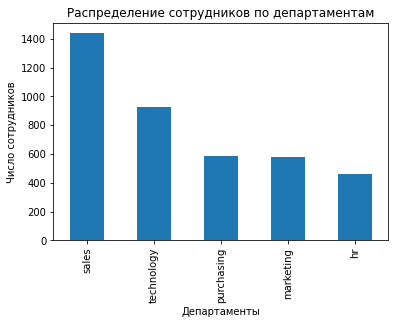

In [50]:
#Строю столбчатую диаграмму для параметра 'dept' в датафрейме train_quit_df
train_quit_df['dept'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по департаментам')
plt.ylabel('Число сотрудников')
plt.xlabel('Департаменты')
plt.show()

**Вывод:** Больше всего сотрудников работает в департаменте sales — около 1500 человек. Почти в два раза меньше — в департаменте technology, где занято примерно 900 сотрудников. В purchasing работают около 700 человек, а в marketing — немного меньше, около 600. HR является самым небольшим департаментом по численности персонала, около 500.

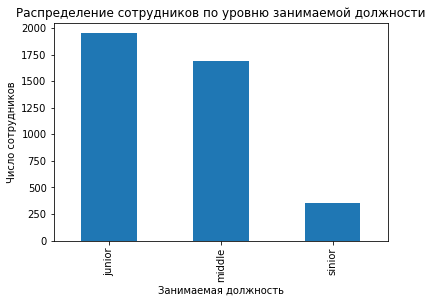

In [51]:
#Строю столбчатую диаграмму для параметра 'level' в датафрейме train_quit_df
train_quit_df['level'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню занимаемой должности')
plt.ylabel('Число сотрудников')
plt.xlabel('Занимаемая должность')
plt.show()

**Вывод:** Наибольшее количество сотрудников занимает должность junior (около 1875). Немного уступает по численности категория middle (1750). А вот senior-сотрудников существенно меньше (375) — их почти в пять раз меньше, чем junior-специалистов.

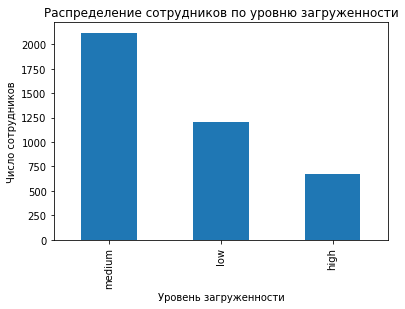

In [52]:
#Строю столбчатую диаграмму для параметра 'workload' в датафрейме train_quit_df
train_quit_df['workload'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по уровню загруженности')
plt.ylabel('Число сотрудников')
plt.xlabel('Уровень загруженности')
plt.show()

**Вывод:** Наиболее распространённый уровень загруженности — medium, его имеют около 2000 сотрудников. На втором месте — уровень low с примерно 1250 сотрудниками, а наименьшее число сотрудников — около 750 — задействовано на уровне high.

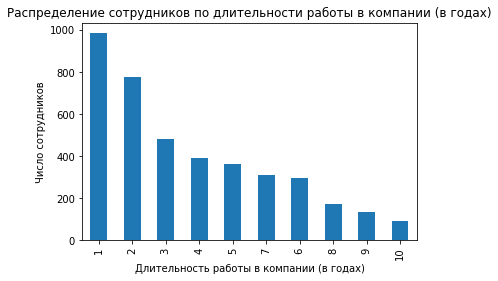

In [53]:
#Строю столбчатую диаграмму для параметра 'employment_years' в датафрейме train_quit_df
train_quit_df['employment_years'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по длительности работы в компании (в годах)')
plt.ylabel('Число сотрудников')
plt.xlabel('Длительность работы в компании (в годах)')
plt.show()

**Вывод:** Большинство сотрудников работают в компании от 1 до 2 лет, в то время как сотрудников с 10-летним стажем — наименьшее количество. Распределение длительности работы левостороннее: значения смещены в сторону меньшего стажа, что может свидетельствовать о высокой текучести кадров или о недавнем росте компании.

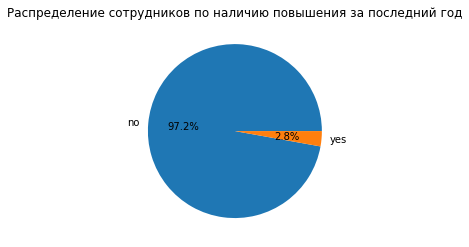

In [54]:
#Строю круговую диаграмму для параметра 'last_year_promo' в датафрейме train_quit_df
train_quit_df['last_year_promo'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию повышения за последний год')
plt.ylabel('')
plt.show()

**Вывод:** За последний год только 2.8% сотрудников получили повышение.

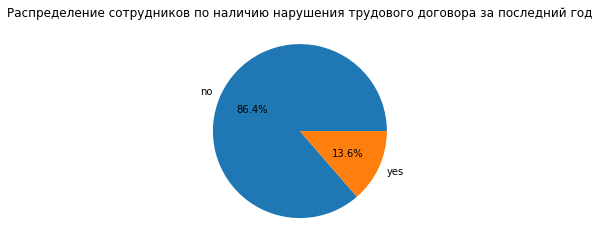

In [55]:
#Строю круговую диаграмму для параметра 'last_year_violations' в датафрейме train_quit_df
train_quit_df['last_year_violations'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию нарушения трудового договора за последний год')
plt.ylabel('')
plt.show()

**Вывод:** За последний год трудовой договор нарушили 13.6% сотрудников.

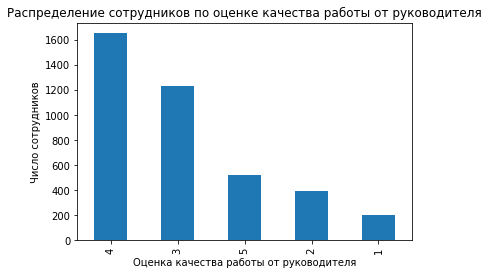

In [56]:
#Строю столбчатую диаграмму для параметра 'supervisor_evaluation' в датафрейме train_quit_df
train_quit_df['supervisor_evaluation'].value_counts().plot(kind='bar');
plt.title('Распределение сотрудников по оценке качества работы от руководителя')
plt.ylabel('Число сотрудников')
plt.xlabel('Оценка качества работы от руководителя')
plt.show()

**Вывод:** Большинство сотрудников — около 1600 человек — получали от руководителей оценку 4. На втором месте по частоте — оценка 3, которую получили примерно 1250 сотрудников. Наименее распространённой является оценка 1, её сотрудники получали крайне редко.

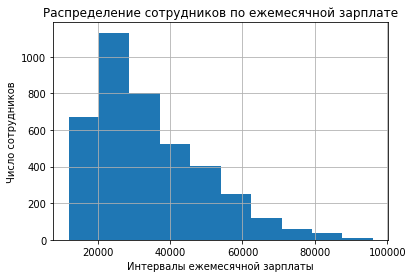

In [57]:
#Строю гистограмму для параметра 'salary' в датафрейме train_quit_df
train_quit_df['salary'].hist();
plt.title('Распределение сотрудников по ежемесячной зарплате')
plt.ylabel('Число сотрудников')
plt.xlabel('Интервалы ежемесячной зарплаты')
plt.show()

**Вывод:** Ежемесячная зарплата сотрудников находится в интервале от 8000 до 100000, при этом пик распределения приходится на зарплату в диапазоне 20000-30000. Распределение левостороннее асимметричное, то есть скошено в сторону низких значений, что потенциально может быть одним из факторов, способствующих увольнению.

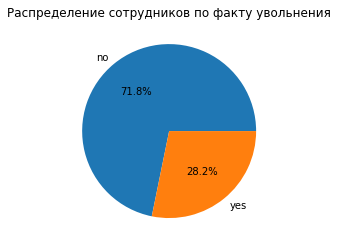

In [58]:
#Строю круговую диаграмму для параметра 'quit' в датафрейме train_quit_df
train_quit_df['quit'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по факту увольнения')
plt.ylabel('')
plt.show()

**Вывод:** По данным тренировочной выборки 28.2% сотрудников уволились из компании.

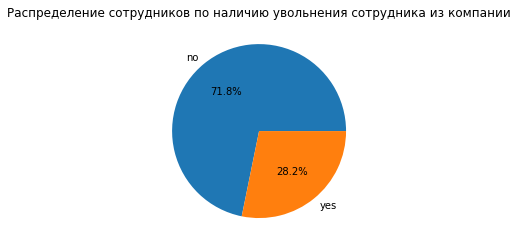

In [59]:
#Строю круговую диаграмму для параметра 'quit' в датафрейме test_target_quit_df
test_target_quit_df['quit'].value_counts().plot(kind='pie', autopct='%.1f%%');
plt.title('Распределение сотрудников по наличию увольнения сотрудника из компании')
plt.ylabel('')
plt.show()

**Вывод:** По данным тестовой выборки 28.2% сотрудников уволились из компании.

**Промежуточный вывод**
Распределения признаков в тестовой и тренировочной выборках схожи. В процессе анализа были выявлены следующие закономерности:

- Департамент \
Наибольшее количество сотрудников работает в департаменте sales — около 1500 человек. Значительно меньше — в technology (900), purchasing (700) и marketing (600). Самый малочисленный департамент — HR (около 500 сотрудников).

- Уровень должности (level) \
Наиболее распространённая должность — junior (1875 сотрудников). Далее следует middle (1750), а senior-специалистов почти в пять раз меньше, что говорит о преобладании менее опытного персонала.

- Загруженность (workload) \
У большинства сотрудников уровень загруженности medium (около 2000 человек). На уровне low — около 1250 сотрудников, и только 750 сотрудников работают при высокой загруженности (high), что говорит о попытке компании равномерно распределять нагрузку.

- Опыт работы (employment_years) \
Преобладающее число сотрудников работает от 1 до 2 лет. Самая низкая доля — у сотрудников с 10-летним стажем. Распределение смещено в сторону меньшего стажа, что может говорить о высокой текучести кадров или о недавнем расширении штата.

- Повышение за последний год (last_year_promo) \
Повышение получили лишь 2.8% сотрудников, что указывает на редкость продвижения по карьерной лестнице.

- Нарушения трудового договора (last_year_violations) 
13.6% сотрудников нарушили условия трудового договора в течение последнего года. Это значимая доля, требующая внимания.

- Оценка от руководителя (supervisor_evaluation) \
Самая частая оценка — 4 (около 1600 сотрудников). Далее по частоте — 3 (примерно 1250 человек). Оценка 1 встречается крайне редко. В целом, сотрудники получают высокие оценки от руководства.

- Ежемесячная зарплата (salary) \
Зарплаты варьируются от 8000 до 100000, но пик приходится на диапазон 20000–30000. Распределение левостороннее — большинство сотрудников получают сравнительно невысокие зарплаты, что может быть фактором риска для удержания персонала.

- Уровень увольняемости (quit) \
По данным обеих выборок, 28.2% сотрудников покинули компанию. Этот показатель подтверждает устойчивую тенденцию к оттоку персонала.

## Анализ портрета уволившегося сотрудника

In [60]:
#Cоздаю список с категориальными признаками для дальнейшего создания портрета 'уволившегося сотрудника'
cat_list = ['dept', 'level', 'workload', 'employment_years', 'last_year_promo', 'last_year_violations']
#Фильтрую датафрейм на уволившихся сотрудников
quit_yes_df = train_quit_df[train_quit_df['quit'] == 'yes']
#Группирую категориальные признаки по факту увольнения сотрудников в тренировочной выборке
for c in cat_list:
    print(quit_yes_df[c].value_counts(normalize=True))
#Рассчитываю среднюю зарплату уволившихся сотрудников в тренировочной выборке
print(train_quit_df.groupby('quit')['salary'].mean())
#Рассчитываю среднюю оценку от руководителя  уволившихся сотрудников в тренировочной выборке
print(quit_yes_df['supervisor_evaluation'].value_counts(normalize=True))

sales         0.360816
technology    0.244681
purchasing    0.147163
marketing     0.144504
hr            0.102837
Name: dept, dtype: float64
junior    0.889184
middle    0.095745
sinior    0.015071
Name: level, dtype: float64
low       0.460106
medium    0.432624
high      0.107270
Name: workload, dtype: float64
1     0.531028
2     0.257092
3     0.144504
4     0.023936
5     0.020390
6     0.008865
7     0.006206
8     0.002660
9     0.002660
10    0.002660
Name: employment_years, dtype: float64
no     0.999113
yes    0.000887
Name: last_year_promo, dtype: float64
no     0.797872
yes    0.202128
Name: last_year_violations, dtype: float64
quit
no     37702.228412
yes    23885.106383
Name: salary, dtype: float64
3    0.463652
4    0.253546
2    0.145390
1    0.084220
5    0.053191
Name: supervisor_evaluation, dtype: float64


**Вывод:** Анализ показал, что департамент не оказывает заметного влияния на увольнение — уволившиеся распределены по отделам пропорционально общей численности. Наиболее подвержены увольнению junior-сотрудники с низкой или средней нагрузкой и стажем 1–3 года, что подтверждает высокую текучесть на ранних этапах карьеры. Повышение за последний год почти никто не получал среди уволившихся, а треть из них нарушала трудовой договор, что может свидетельствовать о сниженной вовлечённости. Наиболее часто увольнялись сотрудники со средней оценкой от руководителя (3). Кроме того, средняя зарплата уволившихся (23 885) существенно ниже, чем у оставшихся (37 702), что подчёркивает роль низкой оплаты труда как ключевого фактора увольнения.

In [61]:
#Объединяю тестовые выборки из задачи 1 с тестовой выборкой задачи 2
test_quit_job_sat_df = pd.merge(merged_test_df, test_target_quit_df, on='id', how='outer')
display(test_quit_job_sat_df)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.79,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.72,no
2,467458,sales,middle,low,5,no,no,4,19200,0.64,no
3,418655,sales,middle,low,6,no,no,4,19200,0.60,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.75,no
...,...,...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400,0.56,yes
1996,109582,technology,middle,low,3,no,no,2,21600,0.14,yes
1997,305653,technology,junior,low,1,no,no,3,14400,0.11,yes
1998,160233,technology,middle,low,8,no,no,1,32400,0.43,no


[]

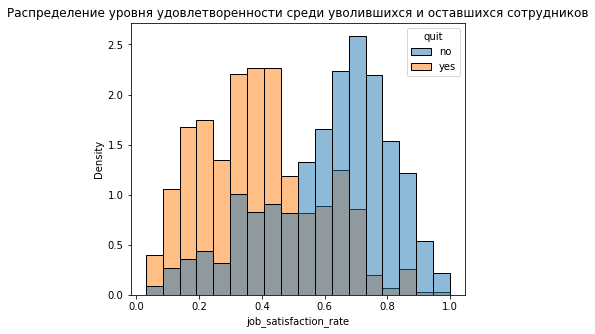

In [62]:
plt.figure(figsize=(6,5))
sns.histplot(data=test_quit_job_sat_df, x='job_satisfaction_rate', hue='quit', stat='density', common_norm=False);
plt.title('Распределение уровня удовлетворенности среди уволившихся и оставшихся сотрудников')
plt.plot()

**Вывод:** Сотрудники, у которых высокий уровень удовлетворённости (> 0.6), чаще остаются в компании, а сотрудники, у которых низкий уровень удовлетворённости (< 0.4), чаще увольняются.

**Промежуточный вывод:** \
Больше всего сотрудников работает в департаменте sales, наименьшее число — в HR. Основную массу составляют junior- и middle-специалисты, тогда как senior-сотрудников почти в 5 раз меньше.

Наиболее распространён уровень загрузки — средний, а большинство сотрудников работают в компании 1–2 года, что может указывать на высокую текучесть или недавний рост компании.

За последний год менее 3% сотрудников получили повышение, при этом 13.6% нарушили трудовой договор. Чаще всего сотрудники получают от руководителя оценку 4, реже — 1.

Зарплаты варьируются от 8 000 до 100 000, но чаще встречаются в диапазоне 20 000–30 000. Распределение скошено в сторону низких значений, что может быть фактором оттока.

Уволилось 28.2% сотрудников. Наибольшая склонность к увольнению наблюдается у junior-сотрудников с низкой/средней загрузкой и стажем до 3 лет. Среди уволившихся почти никто не получал повышения, а треть нарушала трудовой договор. Средняя зарплата уволившихся существенно ниже (23 885 против 37 702).

Анализ подтвердил гипотезу: низкий уровень удовлетворённости работой (в среднем 0.4) связан с большей вероятностью увольнения, тогда как сотрудники с высоким уровнем (в среднем 0.6) чаще остаются в компании.

## Добавление нового входного признака

In [63]:
#Предсказываю значения 'job_satisfaction_rate' в тренировочной выборке второй задачи
train_quit_df['job_satisfaction_rate'] = best_model.predict(train_quit_df.drop(columns=['id','quit']))
display(train_quit_df)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.650000
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.826111
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.380000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000
...,...,...,...,...,...,...,...,...,...,...,...
3995,588809,sales,junior,medium,4,no,no,3,26400,no,0.550000
3996,672059,sales,middle,high,9,no,no,4,52800,no,0.860000
3997,536432,purchasing,junior,low,2,no,yes,4,12000,yes,0.520000
3998,692133,purchasing,middle,medium,2,no,no,4,33600,no,0.580000


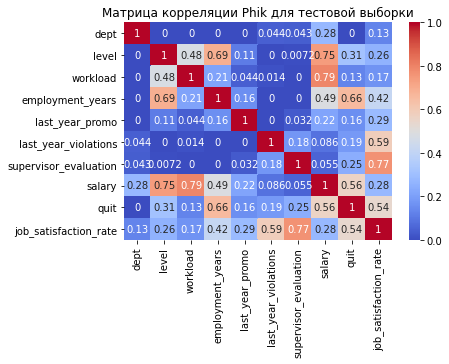

In [64]:
#Делаем корреляционный анализ для тренировочной выборки задачи 2 
corr_matrix_test_3 = train_quit_df.drop(columns='id').phik_matrix(interval_cols = ['job_satisfaction_rate', 'salary'])
sns.heatmap(corr_matrix_test_3, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции Phik для тестовой выборки')
plt.show()

**Вывод:** В результате корреляционного анализа тренировочной выборки были выявлены несколько заметных взаимосвязей между признаками:

Сильная высокая положительная корреляция наблюдается между ежемесячной зарплатой и:
- уровнем занимаемой должности (0.75)
- уровнем загруженности (0.79) \
Это указывает на то, что зарплата существенно зависит как от должности, так и от объёма выполняемой работы.

Также была выявлена высокая корреляция между:
- оценкой руководителя и уровнем удовлетворённости сотрудника (0.77), что логично — положительная оценка напрямую влияет на восприятие сотрудником своей работы.
- стажем в компании и уровнем должности (0.69), что отражает естественное продвижение по карьерной лестнице со временем
- стажем в компании и фактом увольнения (0.66).

In [65]:
#Добавляю предсказанные лучшей моделью значения удовлетворенности к входным признакам задачи 2
job_sat_pred_df = X_test_pred[['id', 'Предсказанные значения']]
test_features_df = pd.merge(test_features_df, job_sat_pred_df, on='id', how='outer' )
test_features_df = test_features_df.rename(columns={'Предсказанные значения':'job_satisfaction_rate'})
#Объединяю данных датафреймов 'test_features_df' и 'test_target_quit_df' по индексу для дальнейшего анализа
merged_test_quit_df = pd.merge(test_features_df, test_target_quit_df, on='id', how='outer')
display(merged_test_quit_df)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046,marketing,junior,medium,2,no,no,5,28800,0.866667,no
1,686555,hr,junior,medium,1,no,no,4,30000,0.681429,no
2,467458,sales,middle,low,5,no,no,4,19200,0.657143,no
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,no
4,789145,hr,middle,medium,5,no,no,5,40800,0.760000,no
...,...,...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400,0.505000,yes
1996,109582,technology,middle,low,3,no,no,2,21600,0.100000,yes
1997,305653,technology,junior,low,1,no,no,3,14400,0.240000,yes
1998,160233,technology,middle,low,8,no,no,1,32400,0.580000,no


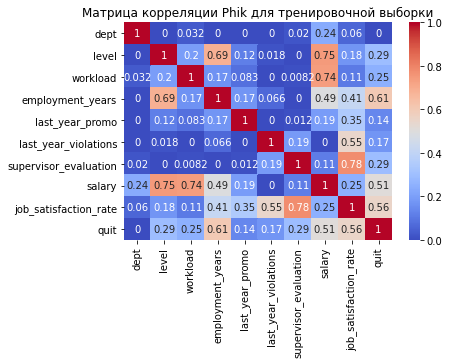

In [66]:
#Делаем корреляционный анализ для тестовой выборки задачи 2
corr_matrix_test_2 = merged_test_quit_df.drop(columns='id').phik_matrix(interval_cols = ['job_satisfaction_rate', 'salary'])
sns.heatmap(corr_matrix_test_2, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции Phik для тренировочной выборки')
plt.show()

**Вывод:** В результате корреляционного анализа тестовой выборки были выявлены несколько заметных взаимосвязей между признаками:

Сильная высокая положительная корреляция наблюдается между ежемесячной зарплатой и:
- уровнем занимаемой должности (0.75)
- уровнем загруженности (0.74) \
Это указывает на то, что зарплата существенно зависит как от должности, так и от объёма выполняемой работы.

Также была выявлена высокая корреляция между:
- оценкой руководителя и уровнем удовлетворённости сотрудника (0.78), что логично — положительная оценка напрямую влияет на восприятие сотрудником своей работы.
- стажем в компании и уровнем должности (0.69), что отражает естественное продвижение по карьерной лестнице со временем
- стажем в компании и фактом увольнения (0.61).

## Подготовка данных

In [67]:
#Создание константы RANDOM_STATE
RANDOM_STATE = 42

#Сохраняю переменные целевого признака и входных признаков в X_train_1, X_test_1, y_train_1, y_test_1, исключив 'id'
X_train_1 = train_quit_df.drop(columns=['id', 'quit'])
X_test_1 = merged_test_quit_df.drop(columns=['id', 'quit'])
y_train_1 = train_quit_df['quit']
y_test_1 = merged_test_quit_df['quit']

In [68]:
#Проверяю размерности получившихся df
print(X_train_1.shape, X_test_1.shape, y_train_1.shape, y_test_1.shape)

#Создаю списки категориальных и количественных признаков
ohe_columns_1 = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns_1 = ['level', 'workload']
num_columns_1 = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

#Создаю общий пайплайн для подготовки данных
data_preprocessor_1 = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns_1),
        ('ord', ord_pipe, ord_columns_1),
        ('num', num_pipe, num_columns_1)
    ],
    remainder='passthrough'
)


(4000, 9) (2000, 9) (4000,) (2000,)


## Обучение модели

In [69]:
#Создаю итоговый пайплайн через подготовку данных и модели 
pipe_final_1 = Pipeline(
    [
        ('preprocessor', data_preprocessor_1),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE)) #placeholder
    ]
)

#Кодирую целевой признак
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_1)
y_test_encoded = le.transform(y_test_1)

#Убеждаюсь в то что порядок классов соответствует значениям целевого признака: 'no' = 0 и 'yes' = 1
print(le.classes_)

#Создаю словарь с гиперпараметрами для перебора в GridSearchCV
param_1 = {
    'preprocessor__num':[
        StandardScaler(),
        MinMaxScaler(),
        RobustScaler()
    ],
    'models': [
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        SVC(probability=True, random_state=RANDOM_STATE),  # обязательно probability=True
        KNeighborsClassifier()
    ]
}

#Ищу лучшие гиперпараметры и модель через GridSearchCV
rs_1 = RandomizedSearchCV(
    pipe_final_1,
    param_1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
rs_1.fit(X_train_1, y_train_encoded)

print('Лучшая модель и её параметры при RandomizedSearchCV:\n\n', rs_1.best_estimator_, rs_1.best_score_)

['no' 'yes']


/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Лучшая модель и её параметры при RandomizedSearchCV:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('SimpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
     

**Вывод:** По результатам подбора гиперпараметров с использованием GridSearchCV и сравнительного анализа моделей (DecisionTreeClassifier, SVC, KNeighborsClassifier), наилучшие результаты показала модель SVC(probability=True, random_state=42), достигнув значения метрики ROC-AUC=0.93.

In [70]:
#Предсказываю значения целевого признака в тестовой выборке с использованием лучшей модели
best_model_1 = rs_1.best_estimator_
y_pred_1 = best_model_1.predict(X_test_1)
y_proba = best_model_1.predict_proba(X_test_1)[:, 1]

# Сохраняю в датафрейм для дальнейшего анализа
X_test_pred_1 = test_features_df.copy()
X_test_pred_1['Истинные значения'] = y_test_encoded
X_test_pred_1['Предсказанные значения'] = y_pred_1
X_test_pred_1['Вероятность увольнения сотрудника'] = y_proba
print('Значение метрики ROC-AUC:', roc_auc_score(y_test_encoded, y_proba))
display(X_test_pred_1)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Значение метрики ROC-AUC: 0.9260332088741381


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,Истинные значения,Предсказанные значения,Вероятность увольнения сотрудника
0,485046,marketing,junior,medium,2,no,no,5,28800,0.866667,0,0,0.004044
1,686555,hr,junior,medium,1,no,no,4,30000,0.681429,0,0,0.069701
2,467458,sales,middle,low,5,no,no,4,19200,0.657143,0,0,0.053932
3,418655,sales,middle,low,6,no,no,4,19200,0.655000,0,0,0.044451
4,789145,hr,middle,medium,5,no,no,5,40800,0.760000,0,0,0.026110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,393147,marketing,junior,low,3,no,no,3,20400,0.505000,1,1,0.811388
1996,109582,technology,middle,low,3,no,no,2,21600,0.100000,1,0,0.426506
1997,305653,technology,junior,low,1,no,no,3,14400,0.240000,1,1,0.994827
1998,160233,technology,middle,low,8,no,no,1,32400,0.580000,0,0,0.050249


**Промежуточный вывод:** Сравнивать качество двух моделей напрямую некорректно, поскольку они решают разные задачи: первая — задачу регрессии, вторая — классификации. Тем не менее, обе модели показали хорошие результаты в рамках своих метрик:
- для первой модели SMAPE = 14.49, что соответствует требуемому уровню ≤ 15;
- для второй модели ROC-AUC = 0.93, что превышает порог 0.91, установленный заданием.

**Итоговый вывод по второй задаче:** \
HR-департамент компании «Работа с заботой» предоставил данные с целью разработки модели, предсказывающей факт увольнения сотрудника на основе характеристик персонала. В проекте были реализованы этапы предобработки, исследовательского анализа и построения модели классификации.

1. Предобработка данных \
Входные данные включали тренировочную выборку из 4000 сотрудников и тестовую — из 2000. В ходе обработки была выявлена и исправлена орфографическая ошибка в значении столбца level в датасете train_quit_df. Явные дубликаты в данных отсутствовали. Дополнительно в тестовую выборку был добавлен признак predicted_job_satisfaction_rate, полученный с использованием модели, обученной в первой части проекта.

2. Исследовательский анализ \
Проведён анализ распределений признаков и факторов, потенциально влияющих на увольнение. Основные выводы:
- Наибольшее количество сотрудников работает в департаменте sales, наименьшее — в HR.
- Большинство — это junior- и middle-сотрудники, у senior- специалистов доля минимальна.
- Распределение загруженности смещено в сторону среднего уровня (medium).
- Наиболее часто встречающийся стаж — 1–2 года, что может свидетельствовать о высокой текучести.
- Лишь 2.8% сотрудников получали повышение, тогда как 13.6% нарушали трудовой договор.
- Большинство сотрудников имеют оценку 4 от руководителя.
- Зарплаты распределены неравномерно, с пиком в диапазоне 20 000–30 000, преобладают низкие значения.
- Средняя зарплата уволившихся составила 23 885, у оставшихся — 37 702.
- Уровень удовлетворённости оказался важным предиктором: уволившиеся имели среднее значение 0.4, оставшиеся — 0.6.

3. Моделирование \
Для задачи классификации были протестированы алгоритмы DecisionTreeClassifier, KNeighborsClassifier и SVC. По результатам подбора гиперпараметров с использованием RandomizedSearchCV наилучшую производительность показала модель SVC(probability=True, random_state=42), достигнув значения метрики ROC-AUC = 0.93 на тестовой выборке. Это подтверждает высокое качество прогноза с точки зрения бизнес-задачи и позволяет рекомендовать модель для использования в HR-аналитике компании.

**Рекомендации для HR-департамента**
На основе анализа данных и построенных моделей предлагаются следующие меры для снижения текучести кадров и повышения удовлетворённости сотрудников:

1. Повышение мотивации через материальные стимулы \
- Пересмотреть политику оплаты труда: особенно для сотрудников с низкой зарплатой и на младших позициях.
- Ввести бонусные программы за достижения, соблюдение дисциплины и длительность работы.

2. Поддержка новых сотрудников
- Внедрить программы адаптации и наставничества для сотрудников с опытом работы <2 лет.
- Предоставлять обратную связь и помощь в профессиональном развитии на раннем этапе.

3.Карьерный рост и развитие
- Повысить прозрачность процессов повышения.
- Внедрить регулярные обзоры развития и потенциального карьерного роста.

4.Улучшение условий труда и внутреннего климата
- Организовать комфортное рабочее пространство и гибкий график при необходимости.
- Развивать культуру открытого общения между руководством и сотрудниками для улучшения взаимопонимания и доверия.

5.Мониторинг удовлетворённости
- Использовать модель предсказания удовлетворённости для раннего выявления рисков.
- Регулярно собирать обратную связь (опросы, встречи 1:1) и оперативно реагировать на тревожные сигналы.